In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [55]:
df=pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [56]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [58]:
df.shape

(200, 5)

In [59]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [60]:
#df.rename({"Annual Income (k$)" :"Income","Spending Score (1-100)":"Spending_score"}, inplace=True, axis=1)
df.rename(columns={"Annual Income (k$)" :"Income","Spending Score (1-100)":"spending_score"}, inplace=True)

df.head()

,CustomerID,Gender,Age,Income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [61]:
df.describe()

,CustomerID,Age,Income,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


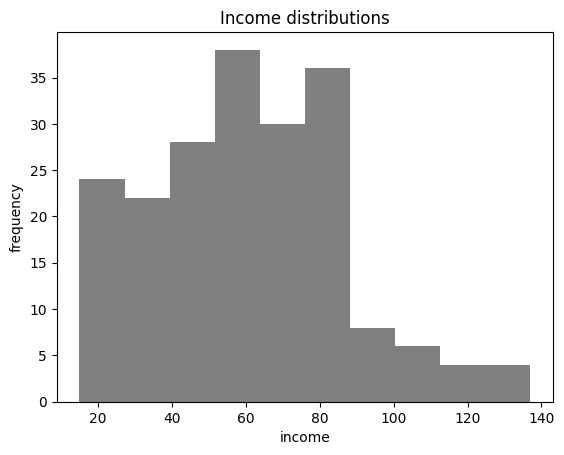

In [62]:
df.Income.plot.hist(color="grey")
plt.xlabel("income")
plt.ylabel("frequency")
plt.title("Income distributions")
plt.show()

In [63]:
data=df.copy()

In [64]:
df['Cluster']=np.where(df['Income'] >= 90, "High earners", np.where(df['Income'] < 50, "Medium income", "Low income"))
df.head()

,CustomerID,Gender,Age,Income,spending_score,Cluster
0,1,Male,19,15,39,Medium income
1,2,Male,21,15,81,Medium income
2,3,Female,20,16,6,Medium income
3,4,Female,23,16,77,Medium income
4,5,Female,31,17,40,Medium income


In [65]:
x=df[df['Cluster'] == "Medium income"].count()
x

,0
CustomerID,72
Gender,72
Age,72
Income,72
spending_score,72
Cluster,72


In [66]:
medium_income_count = df[df['Cluster'] == "Medium income"].shape[0]
medium_income_count

72

In [67]:
df["Cluster"].value_counts()

,count
Cluster,
Low income,106
Medium income,72
High earners,22


In [68]:
df.groupby("Cluster")["Income"].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
High earners,22.0,108.181818,13.661334,93.0,98.25,103.0,118.25,137.0
Low income,106.0,69.377358,10.651584,50.0,61.00,70.0,78.00,88.0
Medium income,72.0,33.027778,11.091136,15.0,22.50,33.5,43.00,49.0


In [69]:
#standardizing the income column
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [70]:
df.head()

,CustomerID,Gender,Age,Income,spending_score,Cluster
0,1,Male,19,15,39,Medium income
1,2,Male,21,15,81,Medium income
2,3,Female,20,16,6,Medium income
3,4,Female,23,16,77,Medium income
4,5,Female,31,17,40,Medium income


In [71]:
col=['Age','Income','spending_score']
data_scaled=df.copy()

In [72]:
col=['Age','Income','spending_score']  # Changed 'spending_score' to 'Spending_score'
data_scaled=df.copy()
data_scaled[col]=scaler.fit_transform(data_scaled[col])
data_scaled.head()

,CustomerID,Gender,Age,Income,spending_score,Cluster
0,1,Male,-1.424569,-1.738999,-0.434801,Medium income
1,2,Male,-1.281035,-1.738999,1.195704,Medium income
2,3,Female,-1.352802,-1.700830,-1.715913,Medium income
3,4,Female,-1.137502,-1.700830,1.040418,Medium income
4,5,Female,-0.563369,-1.662660,-0.395980,Medium income


In [73]:
data_scaled[col].describe().round(2)

,Age,Income,spending_score
count,200.00,200.00,200.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.50,-1.74,-1.91
25%,-0.72,-0.73,-0.60
50%,-0.20,0.04,-0.01
75%,0.73,0.67,0.89
max,2.24,2.92,1.89


calculating the cdist

In [74]:
sel_cols=["Income","spending_score"]
cust3=data_scaled[sel_cols].iloc[0:3]
print(cust3)


     Income  spending_score
0 -1.738999       -0.434801
1 -1.738999        1.195704
2 -1.700830       -1.715913


In [75]:
from scipy.spatial.distance import cdist
cdist(cust3,cust3,metric="euclidean")

array([[0.        , 1.63050555, 1.28167999],
       [1.63050555, 0.        , 2.91186723],
       [1.28167999, 2.91186723, 0.        ]])

In [76]:
np.sqrt((-1.739 + 1.739)**2 + (-0.4348 - 1.1957)**2)

1.6305

In [77]:

"""def calculate_distance_matrix(data, columns, num_customers):
  cust_subset = data[columns].iloc[0:num_customers]    # data_scaled["Income"].iloc[0;3]
  return cdist(cust_subset, cust_subset, metric="euclidean")


calculate_distance_matrix(data_scaled, ["Income", "spending_score"], 3)"""


'def calculate_distance_matrix(data, columns, num_customers):\n  cust_subset = data[columns].iloc[0:num_customers]    # data_scaled["Income"].iloc[0;3]\n  return cdist(cust_subset, cust_subset, metric="euclidean")\n\n\ncalculate_distance_matrix(data_scaled, ["Income", "spending_score"], 3)'

  """Calculates the distance matrix for specified columns and number of customers.

  Args:
    data: DataFrame containing the data.
    columns: List of column names for distance calculation.
    num_customers: Number of customers to consider (rows).

  Returns:
    A distance matrix (NumPy array).
  """

KMeans Clustering

In [80]:
data_scaled.head()

,CustomerID,Gender,Age,Income,spending_score,Cluster
0,1,Male,-1.424569,-1.738999,-0.434801,Medium income
1,2,Male,-1.281035,-1.738999,1.195704,Medium income
2,3,Female,-1.352802,-1.700830,-1.715913,Medium income
3,4,Female,-1.137502,-1.700830,1.040418,Medium income
4,5,Female,-0.563369,-1.662660,-0.395980,Medium income


In [78]:
from sklearn.cluster import KMeans

-->for k=3 clusters

In [53]:
sel_cols=["Income","spending_score"]
model=KMeans(n_clusters=3, random_state=42)
model.fit(data_scaled[sel_cols])

KMeans(n_clusters=3, random_state=42)

In [82]:
data_scaled["Cluster"]=model.predict(data_scaled[sel_cols])
data_scaled.head()

,CustomerID,Gender,Age,Income,spending_score,Cluster
0,1,Male,-1.424569,-1.738999,-0.434801,2
1,2,Male,-1.281035,-1.738999,1.195704,2
2,3,Female,-1.352802,-1.700830,-1.715913,2
3,4,Female,-1.137502,-1.700830,1.040418,2
4,5,Female,-0.563369,-1.662660,-0.395980,2


In [83]:
data_scaled.Cluster.value_counts()

,count
Cluster,
2,123
1,39
0,38


In [84]:
data_scaled[sel_cols].head(3)

,Income,spending_score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913


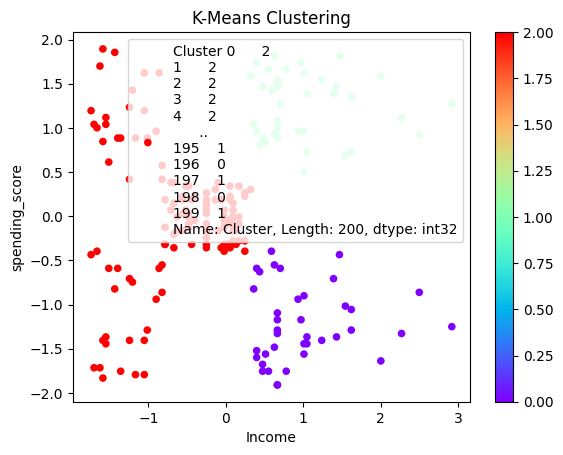

In [86]:
data_scaled.plot.scatter(x="Income",y="spending_score",c=data_scaled.Cluster,label="Cluster "+str(data_scaled["Cluster"]),cmap="rainbow")
plt.xlabel("Income")
plt.ylabel("spending_score")
plt.title("K-Means Clustering")
plt.show()

----> for k=5 clusters

In [87]:
model2=KMeans(n_clusters=5, random_state=42)
model2.fit(data_scaled[sel_cols])

KMeans(n_clusters=5, random_state=42)

In [88]:
data=data_scaled.copy()
data["Cluster"]=model2.predict(data[sel_cols])
data.head()

,CustomerID,Gender,Age,Income,spending_score,Cluster
0,1,Male,-1.424569,-1.738999,-0.434801,4
1,2,Male,-1.281035,-1.738999,1.195704,2
2,3,Female,-1.352802,-1.700830,-1.715913,4
3,4,Female,-1.137502,-1.700830,1.040418,2
4,5,Female,-0.563369,-1.662660,-0.395980,4


In [89]:
data.Cluster.value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


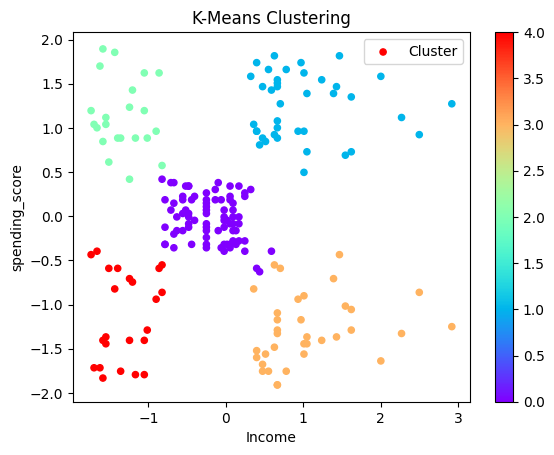

In [96]:
data.plot.scatter(x="Income",y="spending_score",c=data.Cluster,label="Cluster",cmap="rainbow")
plt.xlabel("Income")
plt.ylabel("spending_score")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

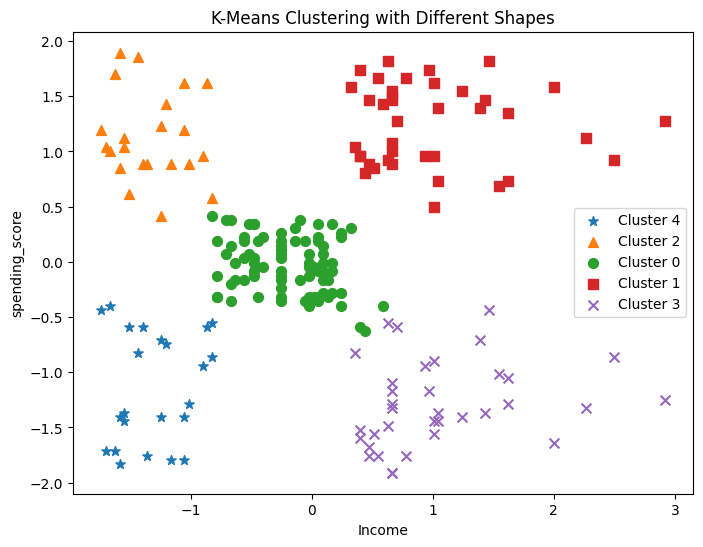

In [95]:
model2 = KMeans(n_clusters=5, random_state=42)
model2.fit(data[sel_cols])
data["Cluster"] = model2.predict(data[sel_cols])


# Create the scatter plot with different shapes for each cluster
plt.figure(figsize=(8, 6))  # Adjust figure size if needed

markers = ['o', 's', '^', 'x', '*'] # Define markers for each cluster

for cluster_label in data["Cluster"].unique():
    cluster_data = data[data["Cluster"] == cluster_label]
    marker_index = cluster_label % len(markers) # Use modulo operator for more than 5 clusters
    plt.scatter(cluster_data["Income"], cluster_data["spending_score"],
                label=f"Cluster {cluster_label}", marker=markers[marker_index], s=50)

plt.xlabel("Income")
plt.ylabel("spending_score")
plt.title("K-Means Clustering with Different Shapes")
plt.legend() # Show the legend to identify clusters
plt.show()

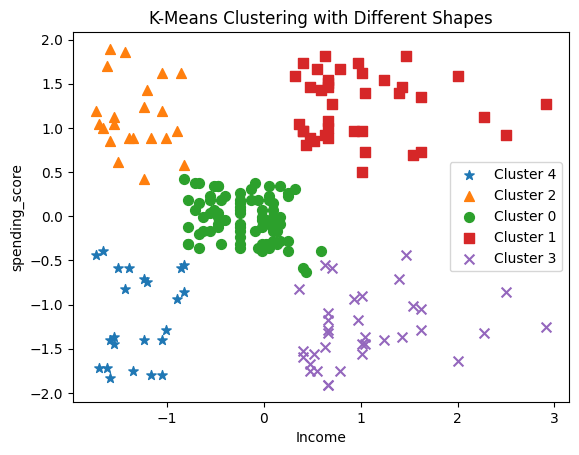

In [102]:
# Unique cluster labels in the dataset
unique_clusters = data["Cluster"].unique()

# Markers for different clusters
markers = ['o', 's', '^', 'x', '*']

# Iterate through each unique cluster
for cluster_label in unique_clusters:

    # Filter data points that belong to the current cluster
    current_cluster_data = data[data["Cluster"] == cluster_label]

    # Assign a marker index based on the cluster label
    marker_index = cluster_label % len(markers)

    # Scatter plot for the current cluster
    plt.scatter(
        current_cluster_data["Income"],          # x-axis: Income
        current_cluster_data["spending_score"],  # y-axis: Spending Score
        label=f"Cluster {cluster_label}",        # Label for the legend
        marker=markers[marker_index],            # Marker shape
        s=50                                     # Marker size
    )

# Add labels, title, and legend to the plot
plt.xlabel("Income")
plt.ylabel("spending_score")
plt.title("K-Means Clustering with Different Shapes")
plt.legend()  # Display the legend
plt.show()    # Show the plot


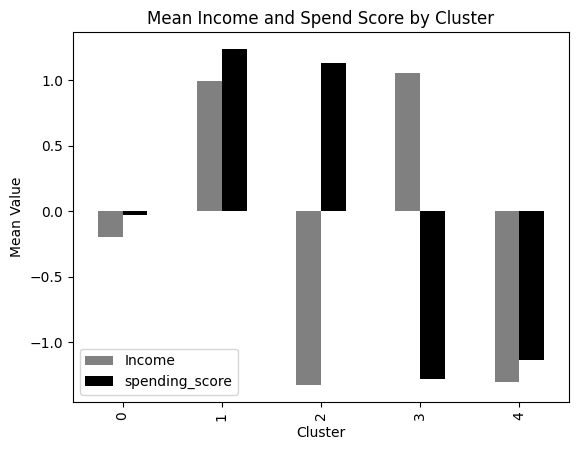

In [99]:
import matplotlib.pyplot as plt

# Group by the 'Cluster' column in the DataFrame 'data'

cluster_means = data.groupby('Cluster')[['Income', 'spending_score']].mean()

# Use cluster_means.index to get the cluster labels for the x-axis

# Use cluster_means['Income'] and cluster_means['spend_score'] as the data for the bars

cluster_means.plot.bar(color=['gray', 'black'])

plt.title('Mean Income and Spend Score by Cluster')

plt.xlabel('Cluster')

plt.ylabel('Mean Value')

plt.show()

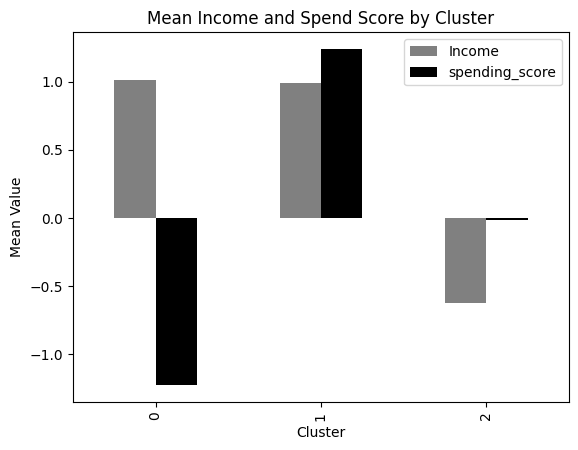

In [101]:
import matplotlib.pyplot as plt

# Group by the 'Cluster' column in the DataFrame 'data'

cluster_means = data_scaled.groupby('Cluster')[['Income', 'spending_score']].mean()



# Use cluster_means.index to get the cluster labels for the x-axis

# Use cluster_means['Income'] and cluster_means['spend_score'] as the data for the bars

cluster_means.plot.bar(color=['gray', 'black'])

plt.title('Mean Income and Spend Score by Cluster')

plt.xlabel('Cluster')

plt.ylabel('Mean Value')

plt.show()